# Downhill ⛷️
### Riding the yield curve — longer bonds pay more, but is it worth the risk?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Is the duration risk worth it?: Not supported](https://img.shields.io/badge/Is_the_duration_risk_worth_it%3F-Not_supported-8b949e?style=flat-square)

A staple of fixed-income lore: hold longer Treasuries to earn the term premium and 'roll down the curve'. Longer bonds *did* pay more than cash — about 2%/year. But the extra return came with far more risk: the Sharpe falls the further out you go, and 2022 took a −23% bite. A real premium that wasn't worth reaching for.

> 📓 **Plain-language layer.** The Sharpe ladder and the term premium are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (downhill/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from downhill import data, strategy as st
ret = data.fetch_panel()                       # cache-first
al = ret[["IEF","SHY","BIL"]].dropna()
tp = st.term_premium(ret)


## The answer first 🎯

| The trade | The data (2003–2026) |
|---|---|
| "Longer bonds pay more" | True: IEF +3.3%/yr vs cash +1.4%, term premium **+2.2%/yr**. |
| "So ride the curve" | But its Sharpe is **0.32** vs cash's **1.82**. |
| "Safe carry" | 2022 carved a **−23%** drawdown. |

## 1 · The claim

Riding the yield curve: hold intermediate/long Treasuries to harvest the term premium (longer bonds yield more) and the roll-down (a bond's yield falls as it ages toward shorter maturities). A classic 'safe' carry trade.

## 2 · So what?

Duration is the biggest lever in a bond portfolio. If extending it earns a premium worth the risk, lengthen; if the extra return is poorly paid, stay short. The 2022 bond crash made the question urgent.

## 3 · How would we even know?

Line up three points on the curve — cash (BIL), 1–3y (SHY), 7–10y (IEF) — and compare return *and* risk-adjusted return. Then isolate the term premium (IEF − cash) and check its Sharpe and its worst drawdown.

In [2]:
rows={'IEF (7-10y)':st.leg_summary(al,'IEF'),'SHY (1-3y)':st.leg_summary(al,'SHY'),'BIL (cash)':st.leg_summary(al,'BIL')}
import pandas as pd
display(pd.DataFrame(rows).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))

,cagr,sharpe,vol_ann,max_drawdown
IEF (7-10y),0.033,0.520,0.067,-0.233
SHY (1-3y),0.019,1.127,0.016,-0.055
BIL (cash),0.014,1.821,0.007,-0.004


## 4 · The teardown

Return rises with duration — but Sharpe *falls*. You're paid for duration, just not enough; the risk grew faster than the reward.

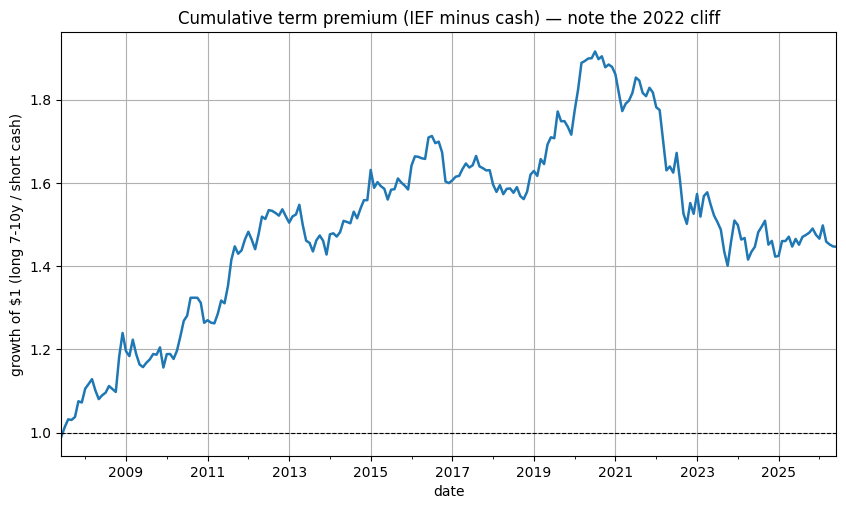

term premium: +2.16%/yr, Sharpe 0.32, t 1.41


In [3]:
ax=(1+tp).cumprod().plot(title='Cumulative term premium (IEF minus cash) — note the 2022 cliff',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1 (long 7-10y / short cash)'); plt.show()
s=st.excess_stats(tp); print(f"term premium: {s['mean_ann']:+.2%}/yr, Sharpe {s['sharpe']:.2f}, t {s['tstat']:.2f}")

**Read it plainly.** A slow climb, then a 2022 cliff. The premium is real but lumpy and thinly paid; cash earned a far higher Sharpe with none of the duration risk.

## 5 · The verdict

**Signal: Real** — term premium +2.2%/yr. **Tradability: Fragile** — Sharpe 0.32, −23% in 2022. **Is the duration risk worth it?: Not supported** — cash's Sharpe was 1.82.

## 6 · Could you actually trade it?

You can buy IEF for a few basis points — but you'd take duration risk that, historically, wasn't well paid. The efficient place on the curve for a cautious investor was the short end; reach for duration only with a view, not for the carry.

## 7 · Going further 🚪

A fixed-income cousin of the carry studies [27 Steamroller](../../27-steamroller/) / [36 Greenback](../../36-greenback/): a real premium whose risk-adjusted appeal is the catch.